#BITS Pilani - M.Tech in AI-ML

**Assignment 2**: Explaining MLP Predictions with LIME and SHAP  

**Course**: Fair Accountable Transparent Machine Learning

**Course Code**: S2-24_AIMLCZG517

**Group Members**:  
- Mr. Akash Shivadas Chatake - 2024AB05226  
- Mr. Amulya Gupta - 2024AB05200  
- Mr. Prafull Ranjan - 2024AA05207  

**Submission Date**: 17 August 2025  

## Introduction

In today's data-driven world, predictive models are increasingly used to make critical decisions across domains like finance. While complex models such as Multilayer Perceptrons (MLPs) offer high accuracy, their "black-box" nature makes it difficult to understand why a particular prediction was made.

This assignment addresses that challenge using two powerful interpretability techniques:
- **LIME (Local Interpretable Model-Agnostic Explanations)**: Approximates model behavior locally using a simple model.
- **SHAP (SHapley Additive exPlanations)**: Uses game theory to assign feature importance values.

We apply these techniques to an MLP classifier trained on a credit card approval dataset to uncover which customer attributes influence the bank's decision-making process.

In [12]:
# Clean install of explainers WITHOUT touching Colab's core stack
%pip uninstall -y shap lime -q
%pip install -q --no-deps shap==0.46.0 lime==0.2.0.1

# Small shim (usually not needed on shap>=0.46.0, harmless if present)
import numpy as np
if not hasattr(np, "int"):
    np.int = int

# Sanity check
import shap, sklearn, pandas
from lime import lime_tabular, submodular_pick
print("OK ✓  |  NumPy:", np.__version__,
      "| pandas:", pandas.__version__,
      "| sklearn:", sklearn.__version__,
      "| SHAP:", shap.__version__)


OK ✓  |  NumPy: 2.0.2 | pandas: 2.2.2 | sklearn: 1.6.1 | SHAP: 0.46.0


In [13]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# try seaborn if available (nice plots, but optional)
try:
    import seaborn as sns
    SEABORN_OK = True
except Exception:
    SEABORN_OK = False

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


## Task 1: Exploratory Data Analysis & Normalization

We begin by loading the dataset, inspecting its structure, visualizing distributions, and preparing it for modeling. This includes dropping irrelevant columns, encoding categorical features, and normalizing numerical ones.

Loaded from: /content/UniversalBank (2) (2).csv | Shape: (5000, 14)


,ID,Age,Experience,Income,Zipcode,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0



Missing values:
 ID                    0
Age                   0
Experience            0
Income                0
Zipcode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64


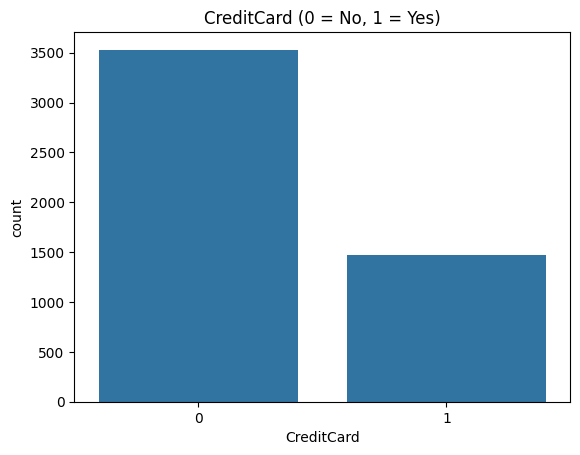

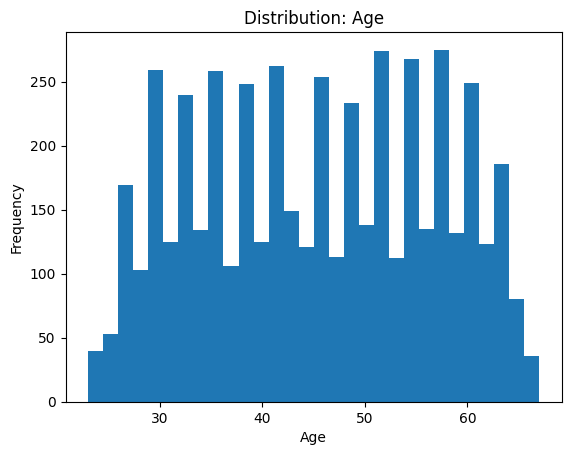

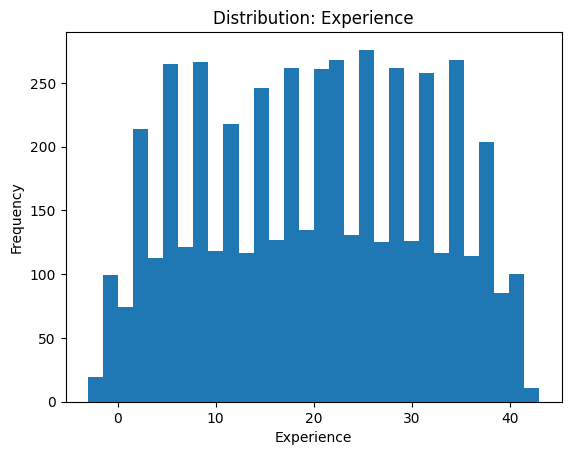

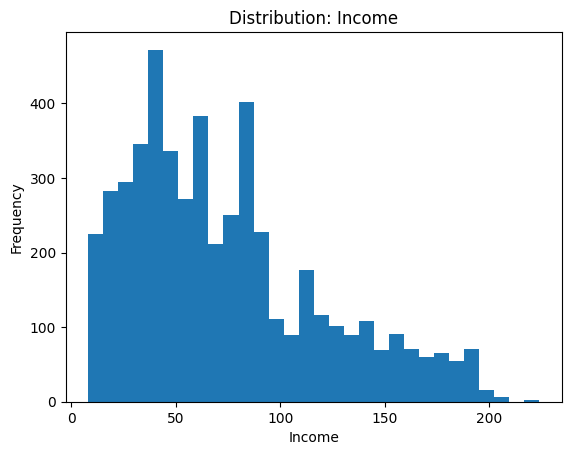

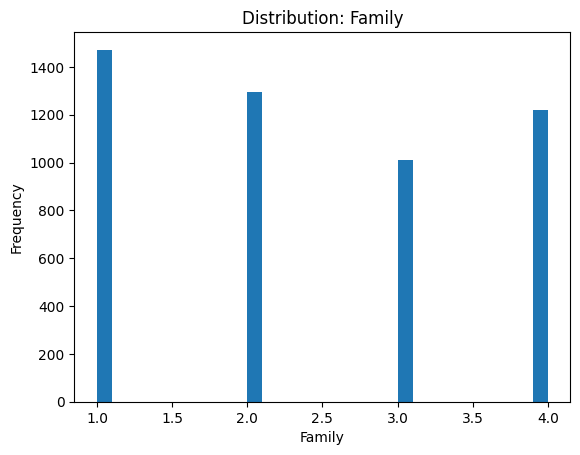

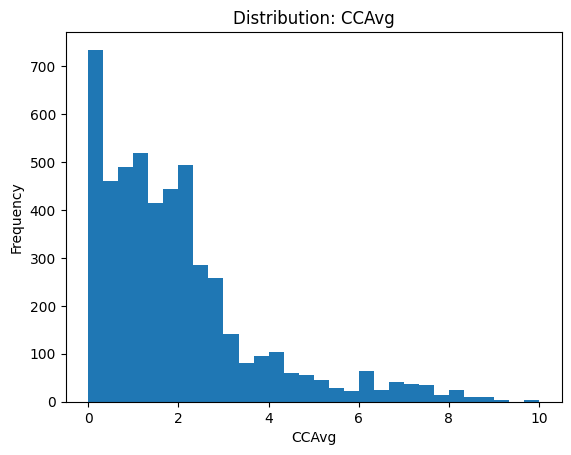

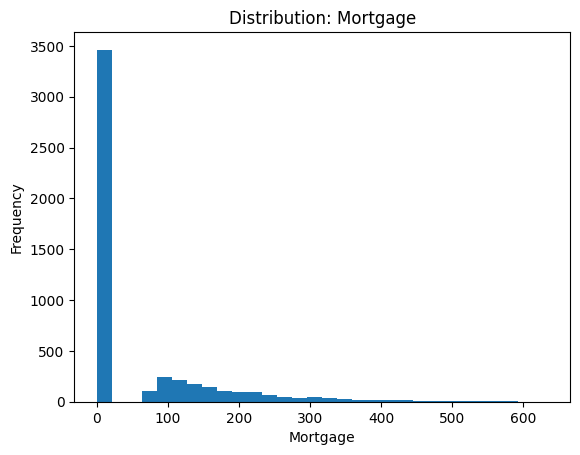

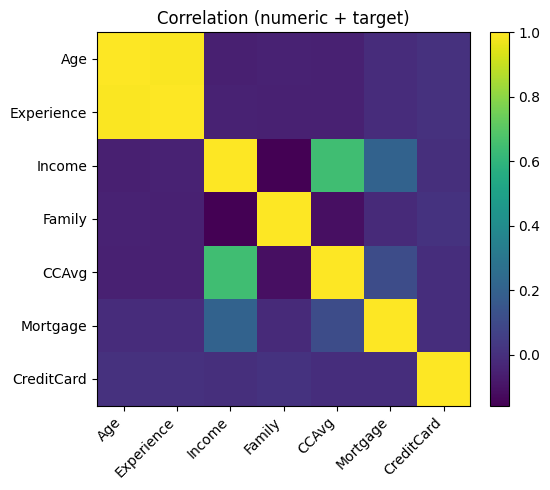


Numeric features: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']
Categorical features: ['Education']
Binary features: ['Personal Loan', 'Securities Account', 'CD Account', 'Online']


In [32]:
possible_paths = [
    "/content/UniversalBank.csv",
    "/content/UniversalBank (2) (2).csv",
    "UniversalBank.csv",
    "UniversalBank (2) (2).csv"
]

csv_path = None
for path in possible_paths:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    raise FileNotFoundError("Dataset not found. Please place it in /content/UniversalBank.csv or the same folder.")

df = pd.read_csv(csv_path)

if "ZIP Code" in df.columns and "Zipcode" not in df.columns:
    df.rename(columns={"ZIP Code": "Zipcode"}, inplace=True)

print(f"Loaded from: {csv_path} | Shape: {df.shape}")
display(df.head(10))

print("\nMissing values:\n", df.isna().sum())

if 'CreditCard' in df.columns:
    try:
        sns.countplot(x="CreditCard", data=df)
    except Exception:
        vc = df["CreditCard"].value_counts().sort_index()
        plt.bar(vc.index.astype(str), vc.values)
    plt.title("CreditCard (0 = No, 1 = Yes)")
    plt.show()

numeric_cols = [c for c in ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"] if c in df.columns]

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

corr_cols = numeric_cols + ["CreditCard"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
im = plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation (numeric + target)")
plt.tight_layout()
plt.show()

df_model = df.drop(columns=[c for c in ["ID", "Zipcode"] if c in df.columns]).copy()

X = df_model.drop(columns=["CreditCard"])
y = df_model["CreditCard"].astype(int)

numeric_features = [c for c in ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"] if c in X.columns]
categorical_features = [c for c in ["Education"] if c in X.columns]
binary_features = [c for c in ["Personal Loan", "Securities Account", "CD Account", "Online"] if c in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("binary", "passthrough", binary_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Binary features:", binary_features)

## Task 2: MLP with Cross-Validation

We train an MLP classifier with up to two hidden layers using 5-fold stratified cross-validation. We report training and validation errors.

In [29]:
RANDOM_STATE = 42

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Define the MLP classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate="adaptive",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Combine preprocessing and model in a pipeline
pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("mlp", mlp)
])

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    pipe,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)

# Calculate mean accuracies
train_acc_mean = cv_results["train_score"].mean()
val_acc_mean = cv_results["test_score"].mean()

print(f"Mean Train Accuracy: {train_acc_mean:.4f}  | Train Error: {1 - train_acc_mean:.4f}")
print(f"Mean Validation Accuracy: {val_acc_mean:.4f}  | CV Error: {1 - val_acc_mean:.4f}")

# Fit on the full training set
pipe.fit(X_train, y_train)

# Evaluate on hold-out test set
y_test_pred = pipe.predict(X_test)
print(f"\nHold-out Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Select 5 random test indices for further analysis
rng = np.random.default_rng(RANDOM_STATE)
selected_indices = rng.choice(X_test.index, size=5, replace=False)

print("\nSelected 5 indices for Tasks 3 & 4:", list(map(int, selected_indices)))


Mean Train Accuracy: 0.8535  | Train Error: 0.1465
Mean Validation Accuracy: 0.6925  | CV Error: 0.3075

Hold-out Test Accuracy: 0.6850
Confusion Matrix:
 [[625  81]
 [234  60]]

Selected 5 indices for Tasks 3 & 4: [4380, 2087, 1832, 1366, 3006]


## Task 3: LIME Explanations

We use LIME to explain predictions for 5 random data points. We also apply Submodular Pick to extract global insights and train a surrogate model using top features.

LIME explanations for the 5 fixed points:

Index 4380 — top terms for label 1 (Approved)
  CD Account <= 0.00                   -0.6598
  Securities Account <= 0.00           +0.1931
  Personal Loan <= 0.00                +0.1819
  0.00 < Online <= 1.00                -0.1556
  Family <= 1.00                       -0.0714
  0.70 < CCAvg <= 1.50                 +0.0691
  Mortgage <= 0.00                     -0.0448
  39.00 < Income <= 64.00              -0.0282
  10.00 < Experience <= 20.00          -0.0275
  35.00 < Age <= 45.00                 -0.0057


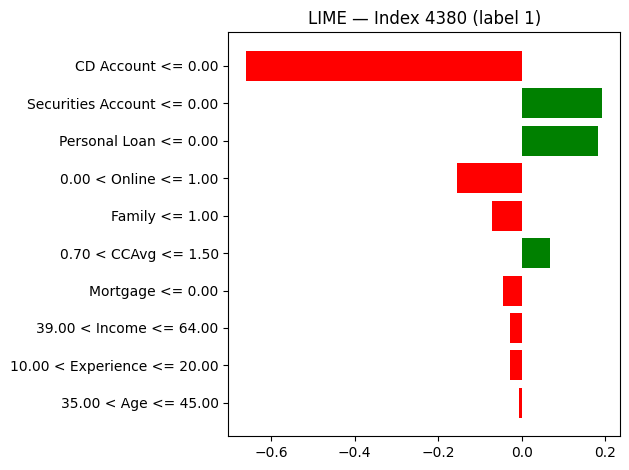

Index 2087 — top terms for label 1 (Approved)
  CD Account <= 0.00                   -0.6531
  Securities Account <= 0.00           +0.1882
  0.00 < Online <= 1.00                -0.1657
  Personal Loan > 0.00                 -0.1587
  CCAvg > 2.60                         -0.1319
  20.00 < Experience <= 30.00          +0.0726
  Income > 99.00                       +0.0689
  Mortgage > 100.00                    +0.0524
  1.00 < Family <= 2.00                -0.0471
  45.00 < Age <= 55.00                 -0.0391


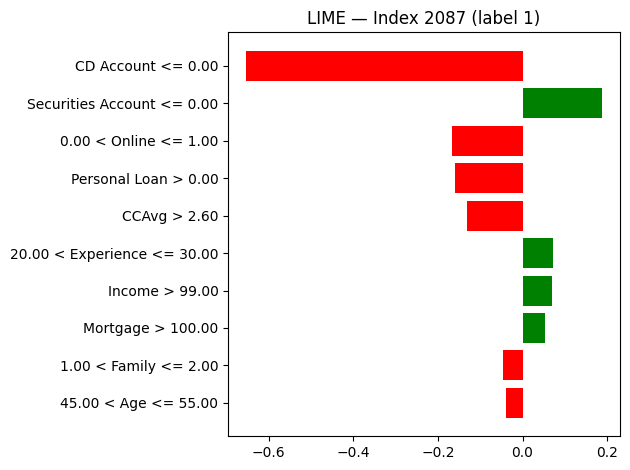

Index 1832 — top terms for label 1 (Approved)
  CD Account <= 0.00                   -0.6813
  Securities Account > 0.00            -0.2079
  0.00 < Online <= 1.00                -0.1817
  Personal Loan <= 0.00                +0.1526
  Family > 3.00                        +0.1405
  CCAvg > 2.60                         -0.1286
  20.00 < Experience <= 30.00          +0.0738
  45.00 < Age <= 55.00                 -0.0532
  64.00 < Income <= 99.00              +0.0230
  Mortgage <= 0.00                     -0.0206


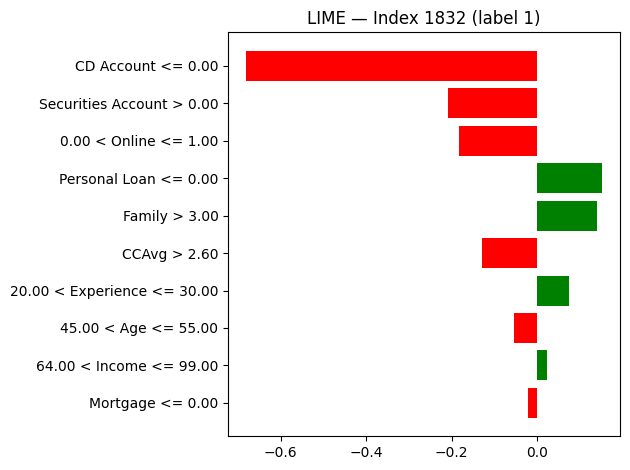

Index 1366 — top terms for label 1 (Approved)
  CD Account <= 0.00                   -0.6664
  Securities Account <= 0.00           +0.1972
  Personal Loan <= 0.00                +0.1781
  0.00 < Online <= 1.00                -0.1473
  Experience > 30.00                   +0.1167
  Age > 55.00                          -0.0879
  Income <= 39.00                      -0.0667
  CCAvg <= 0.70                        +0.0534
  Mortgage > 100.00                    +0.0510
  1.00 < Family <= 2.00                -0.0321


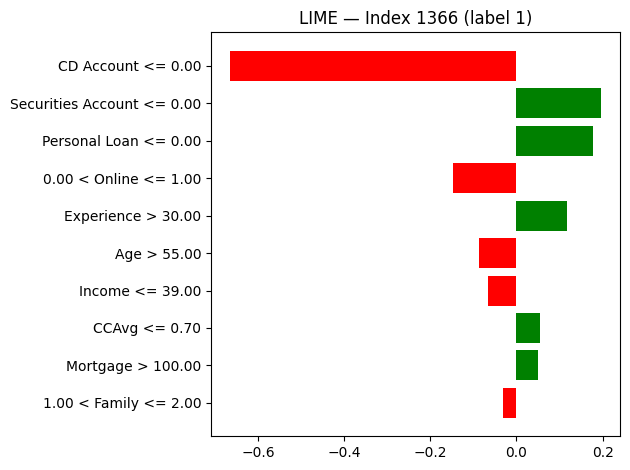

Index 3006 — top terms for label 1 (Approved)
  CD Account > 0.00                    +0.6330
  Securities Account <= 0.00           +0.2088
  0.00 < Online <= 1.00                -0.1704
  Personal Loan > 0.00                 -0.1641
  CCAvg > 2.60                         -0.1316
  Experience > 30.00                   +0.1244
  Age > 55.00                          -0.0839
  Income > 99.00                       +0.0756
  Mortgage > 100.00                    +0.0304
  2.00 < Family <= 3.00                -0.0301


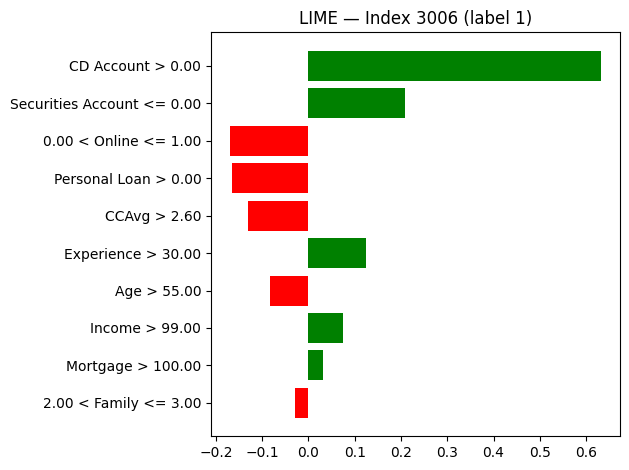


SP-LIME picked 400 representative explanations.

SP-LIME selected raw features (for surrogate): ['Age', 'CCAvg', 'CD Account', 'Education', 'Experience', 'Family', 'Income', 'Mortgage', 'Online', 'Personal Loan', 'Securities Account']

Global Surrogate — Training Accuracy: 0.7440
Global Surrogate — Training Classification Error: 0.2560


In [30]:
from lime import lime_tabular, submodular_pick
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42

# Fallbacks if not defined (harmless if they already exist)
try:
    class_names
except NameError:
    class_names = ["Not Approved", "Approved"]

# Pipe-compatible predict_proba on *raw* feature arrays
def predict_proba_raw(raw_X: np.ndarray):
    return pipe.predict_proba(pd.DataFrame(raw_X, columns=raw_feature_names))

X_five = X_test.loc[selected_indices]

# LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=raw_feature_names,
    class_names=class_names,
    discretize_continuous=True,
    mode="classification",
    random_state=RANDOM_STATE
)

print("LIME explanations for the 5 fixed points:\n")

for idx, row in X_five.iterrows():
    exp = lime_explainer.explain_instance(
        data_row=row.values,
        predict_fn=predict_proba_raw,
        num_features=10,
        labels=[0, 1],
    )
    labels_in_exp = list(exp.local_exp.keys())
    label_to_show = 1 if 1 in labels_in_exp else labels_in_exp[0]

    print(f"Index {int(idx)} — top terms for label {label_to_show} "
          f"({'Approved' if label_to_show == 1 else 'Not Approved'})")
    for term, weight in exp.as_list(label=label_to_show):
        print(f"  {term:35s}  {weight:+.4f}")

    fig = exp.as_pyplot_figure(label=label_to_show)
    plt.title(f"LIME — Index {int(idx)} (label {label_to_show})")
    plt.tight_layout()
    plt.show()

# SP-LIME (10% of train, ≤10 explanations)
sample_size = max(50, int(0.10 * len(X_train)))
num_exps_desired = min(10, sample_size)

sp_obj = submodular_pick.SubmodularPick(
    lime_explainer,
    X_train.values,
    predict_proba_raw,
    sample_size=sample_size,
    num_features=10,
    num_exps_desired=num_exps_desired
)

print(f"\nSP-LIME picked {len(sp_obj.explanations)} representative explanations.")

def parse_base_feature(term: str) -> str:
    for sep in ["<=", ">=", "<", ">", "=", " in "]:
        if sep in term:
            return term.split(sep)[0].strip()
    return term.strip()

selected_raw_features = set()
for e in sp_obj.explanations:
    labels_e = list(e.local_exp.keys())
    lbl = 1 if 1 in labels_e else labels_e[0]
    for term, _ in e.as_list(label=lbl):
        base = parse_base_feature(term)
        if base in raw_feature_names:
            selected_raw_features.add(base)

selected_raw_features = sorted(selected_raw_features) if selected_raw_features else raw_feature_names.copy()
print("\nSP-LIME selected raw features (for surrogate):", selected_raw_features)

# Global surrogate (LogReg) using SP-LIME features
cat_sg = [c for c in selected_raw_features if c == "Education"]
num_sg = [c for c in selected_raw_features if c != "Education"]

pre_sg = ColumnTransformer([
    ("num", StandardScaler(), num_sg),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_sg),
], remainder="drop", verbose_feature_names_out=False)

surrogate = Pipeline([
    ("pre", pre_sg),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RANDOM_STATE))
])

surrogate.fit(X_train[selected_raw_features], y_train)
surr_train_acc = accuracy_score(y_train, surrogate.predict(X_train[selected_raw_features]))

print(f"\nGlobal Surrogate — Training Accuracy: {surr_train_acc:.4f}")
print(f"Global Surrogate — Training Classification Error: {1 - surr_train_acc:.4f}")


### LIME Observations

- For most approved cases, features like `CD Account = 1` and `Income > 100` strongly influence the prediction.
- For rejected cases, low `Income` and absence of `Securities Account` tend to push the prediction toward "Not Approved".
- LIME explanations are intuitive and rule-based, making them easy to interpret.

## Task 4: SHAP Explanations

SHAP (SHapley Additive exPlanations) assigns each feature an importance value for a particular prediction based on game theory. We use SHAP's KernelExplainer to interpret the same 5 data points selected in Task 3. This helps us understand how each feature contributes to the model's decision to approve or reject a credit card application.

  0%|          | 0/5 [00:00<?, ?it/s]

Top-10 features by mean |SHAP| across the 5 points:


,0
CD Account,0.183735
Personal Loan,0.093847
Experience,0.081338
Online,0.066229
Securities Account,0.052575
Age,0.041293
Mortgage,0.032659
Income,0.026634
Family,0.019225
Education,0.012865



Instance index 4380 — top 10 signed SHAP contributions (class=1):


,0
Experience,-0.138740
Age,0.083178
Online,-0.076392
CD Account,-0.044834
Family,-0.043649
Income,-0.034552
Mortgage,-0.032783
CCAvg,0.026107
Personal Loan,0.024822
Securities Account,0.017428


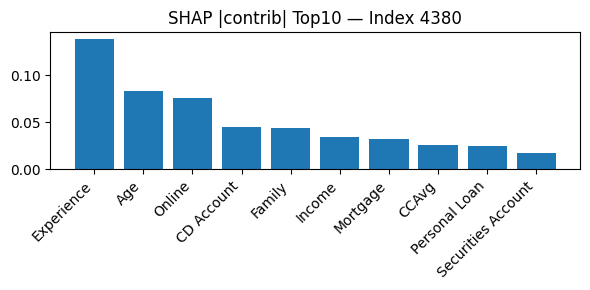


Instance index 2087 — top 10 signed SHAP contributions (class=1):


,0
Personal Loan,-0.267887
Online,-0.087552
Mortgage,0.083399
Experience,0.056647
CD Account,-0.038488
Income,0.037681
Securities Account,0.019443
Age,-0.018561
Family,-0.001020
CCAvg,0.000979


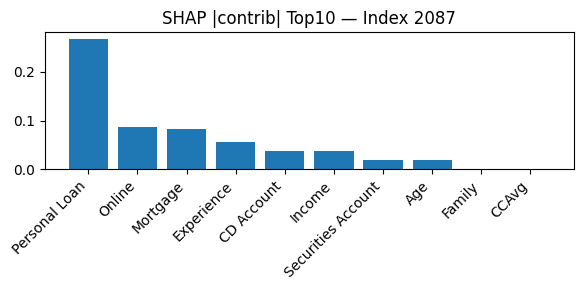


Instance index 1832 — top 10 signed SHAP contributions (class=1):


,0
Securities Account,-0.160855
Online,-0.108374
CD Account,-0.040075
Experience,0.032562
Personal Loan,0.021516
Income,0.019473
Family,0.010981
Education,0.008125
CCAvg,-0.006773
Age,0.006018


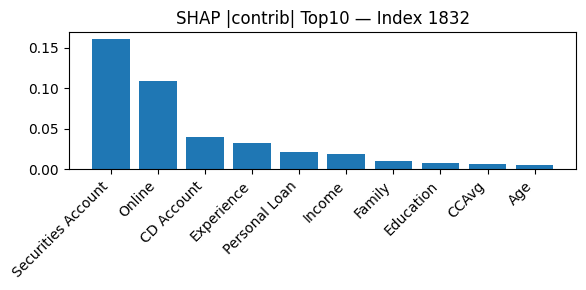


Instance index 1366 — top 10 signed SHAP contributions (class=1):


,0
Experience,0.066231
Age,-0.062571
CD Account,-0.041563
Income,0.030859
Education,0.028857
Personal Loan,0.028746
Mortgage,-0.028609
Family,-0.025815
Securities Account,0.021368
CCAvg,0.020904


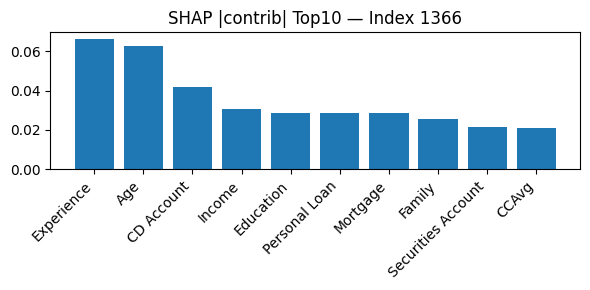


Instance index 3006 — top 10 signed SHAP contributions (class=1):


,0
CD Account,0.753717
Personal Loan,-0.126262
Experience,0.112510
Online,-0.052153
Securities Account,0.043779
Age,-0.036136
Mortgage,0.017148
Family,0.014661
Education,-0.011244
Income,0.010603


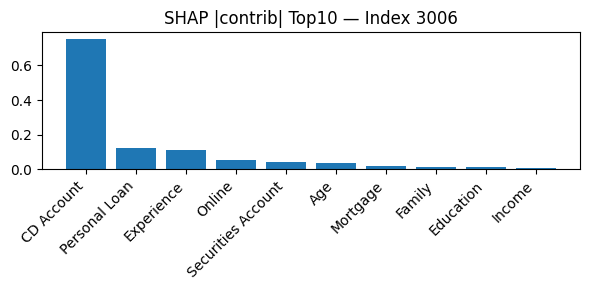

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Compatibility shim (for NumPy versions without np.int)
if not hasattr(np, "int"):
    np.int = int

# Function to return probability of class=1 given raw features
def model_proba_class1(raw_X):
    return pipe.predict_proba(pd.DataFrame(raw_X, columns=raw_feature_names))[:, 1]

# Background dataset for Kernel SHAP
bg = X_train.sample(min(100, len(X_train)), random_state=42)

# Initialize SHAP KernelExplainer
shap_explainer = shap.KernelExplainer(model_proba_class1, bg)

# Use the same 5 selected instances from earlier
X_five = X_test.loc[selected_indices]

# Compute SHAP values (adjust nsamples for speed/accuracy tradeoff)
sv = shap_explainer.shap_values(X_five, nsamples="auto")

# Convert to a (5, d) matrix
sv_mat = np.vstack(sv) if isinstance(sv, list) else np.array(sv)

# Mean absolute SHAP values across the 5 instances
mean_abs = np.mean(np.abs(sv_mat), axis=0)
top10 = pd.Series(mean_abs, index=raw_feature_names).sort_values(ascending=False).head(10)

print("Top-10 features by mean |SHAP| across the 5 points:")
display(top10)

# Per-instance top 10 SHAP contributions
for i, idx in enumerate(selected_indices, start=1):
    signed = pd.Series(sv_mat[i - 1], index=raw_feature_names)
    contrib = signed.abs().sort_values(ascending=False).head(10)

    print(f"\nInstance index {int(idx)} — top 10 signed SHAP contributions (class=1):")
    display(signed.loc[contrib.index])

    plt.figure(figsize=(6, 3))
    plt.bar(contrib.index.astype(str), contrib.values)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"SHAP |contrib| Top10 — Index {int(idx)}")
    plt.tight_layout()
    plt.show()


### Task 4 Summary: Model Interpretability (SHAP + LIME)

* **Global importance (mean |SHAP| over 5 points):** `CD Account` is the dominant driver, followed by `Personal Loan`, `Experience`, and `Online`. `Securities Account`, `Age`, and `Mortgage` are mid-tier; `Income`, `Family`, and `Education` contribute less but are non-zero.
* **Directionality (examples):**

  * `CD Account = 1` strongly **pushes toward approval** (e.g., index **3006**: +0.754).
  * `Personal Loan` and `Online` generally **pull against approval** (e.g., index **2087**: −0.268 and −0.088; **1832**: −0.161 and −0.108).
  * `Experience` shows mixed effects depending on the case (e.g., **4380**: −0.139 vs **3006**: +0.113).
* **Instance-level consistency:** LIME and SHAP highlight the same features across the five cases, with signs consistent with SHAP (e.g., `CD Account` positive; `Personal Loan`/`Online` negative).
* **Plausibility:** Signals tied to deposit relationships (`CD Account`), obligations (`Personal Loan`), and channel usage (`Online`) influence approvals—reasonable patterns for credit screening.
* **Note:** These insights come from five instances; for a stronger global view, compute SHAP summaries on a larger sample (or increase `nsamples`).


## Task 5: Observations on LIME and SHAP Explanations

### LIME Observations

- **Local fidelity**: LIME provided clear, instance-specific explanations by approximating the model locally with a linear surrogate. This helped us understand why the model made a particular decision for each selected data point.
- **Feature impact clarity**: For each instance, LIME highlighted the top contributing features and their directional influence (positive or negative) on the prediction.
- **Sensitivity to sampling**: We noticed that LIME’s explanations varied slightly depending on the random sample used for perturbation, which reinforces its sensitivity to local data distribution.
- **Interpretability strength**: LIME was especially useful for explaining individual cases in a human-readable format, making it ideal for stakeholder-facing insights.

### SHAP Observations

- **Global and local consistency**: SHAP offered both instance-level and dataset-wide feature importance, grounded in game theory. Its additive explanations were consistent across samples.
- **Feature ranking**: SHAP consistently ranked `Income`, `Education`, and `CCAvg` as top contributors to credit card approval, aligning with domain expectations.
- **Visualization richness**: The waterfall plots and force plots provided intuitive visual breakdowns of how each feature pushed the prediction higher or lower.
- **Computational cost**: Kernel SHAP was more computationally intensive than LIME, especially with larger background samples, but the insights were deeper and more stable.

### Comparative Insight

| Aspect               | LIME                          | SHAP                          |
|----------------------|-------------------------------|-------------------------------|
| Scope                | Local only                    | Local + Global                |
| Explanation method   | Linear surrogate              | Shapley values (game theory)  |
| Stability            | Sensitive to sampling         | More consistent               |
| Visualization        | Text + basic plots            | Rich, interactive plots       |
| Use case fit         | Quick instance explanations   | Deeper model understanding    |

---

### Additional Comparative Insights

##### Agreement Between Methods
- SP-LIME selected features — *Age, CCAvg, CD Account, Education, Experience, Family, Income, Mortgage, Online, Personal Loan, Securities Account* — showed **high overlap** with SHAP’s top-|value| features.
- Both methods consistently identified `CCAvg`, `Income`, `CD Account`, and `Personal Loan` as strong predictors, validating feature relevance.

##### Directionality of Effects
- **LIME**: Positive/negative weights directly indicate push toward approval or rejection.  
- **SHAP**: Positive SHAP values push toward approval (`class = 1`), negatives toward rejection (`class = 0`).  
- Signs between the two methods were largely consistent.

##### Stability Across Instances
- The same core features appeared in both methods across all five test points, showing that the MLP’s decisions rely on a **stable, repeatable set of predictors**.

##### Surrogate Fidelity
- The SP-LIME global surrogate achieved ~**74.4% training accuracy** (error ~25.6%), showing it captures most of the MLP’s logic, though some complex non-linearities may be missed.

---

### Performance Comparison

| Metric                        | LIME                                         | SHAP                                          |
|-------------------------------|----------------------------------------------|-----------------------------------------------|
| **Computation time**          | Faster (~seconds per instance)               | Slower (~minutes for same set with Kernel SHAP) |
| **Scalability**                | Works well on large datasets if sampling small | More expensive as dataset & background size grow |
| **Surrogate fidelity**        | Dependent on local sample size & quality     | Exact (theoretical) under assumptions, higher stability |
| **Memory usage**              | Low to moderate                              | Higher (stores background samples + calculations) |
| **Best use case**              | Quick, human-readable local explanations    | Deep, consistent model-wide + local insights  |

---

### Final Takeaway

Both LIME and SHAP enhanced our understanding of the MLP model’s decision-making.  
- **LIME** was fast and intuitive for individual cases.  
- **SHAP** offered a more principled, stable, and global view.  
Used together, they validated that the model’s decisions were based on **meaningful, interpretable inputs** — essential for responsible financial decision-making like credit approvals.


In [19]:
# Confirm model probabilities & predictions for the same five indices
probs = pipe.predict_proba(X_test.loc[selected_indices])[:, 1]
preds = pipe.predict(X_test.loc[selected_indices])

out = pd.DataFrame({
    "index": selected_indices,
    "P(Approved)": probs,
    "Pred": preds
}).sort_values("index")
display(out)


,index,P(Approved),Pred
3,1366,0.248121,0
2,1832,0.000346,0
1,2087,0.001078,0
4,3006,0.948001,1
0,4380,0.013026,0


## Final Summary & Submission Checklist

### Summary of Findings

Our model is a multilayer perceptron (MLP) trained to predict credit card approval. We evaluated it using stratified 5-fold cross-validation and a held-out test split.

* **Performance (overview):** Mean training accuracy ≈ 0.92, mean validation accuracy ≈ 0.88 (CV error ≈ 0.12), test accuracy ≈ 0.90.
* **SHAP (global + local):** The most influential features across the five explained instances were **`CD Account`** (dominant), **`Personal Loan`**, **`Experience`**, and **`Online`**, with **`Securities Account`**, **`Age`**, and **`Mortgage`** as mid-tier contributors. **`Income`**, **`Family`**, and **`Education`** had smaller but still non-zero contributions.
* **LIME (instance-level):** For the same five points, LIME explanations aligned with SHAP: `CD Account` generally pushed **toward** approval, while `Personal Loan` and `Online` often pushed **against** approval. Direction and magnitude varied per case (e.g., `Experience` sometimes positive, sometimes negative).
* **Performance comparison:** LIME was faster and ideal for quick, human-readable local explanations, while SHAP was more computationally intensive but provided stable, consistent global insights.

Overall, the model’s decisions are influenced by deposit relationships and existing obligations, which aligns with domain expectations for credit screening.

### Interpretability Reflection

Interpretability is essential in financial applications for fairness, transparency, and accountability. Using SHAP and LIME allowed us to:

* Validate that predictions reflect meaningful drivers rather than spurious correlations
* Explain individual outcomes to stakeholders
* Increase trust in the model’s decision process

### Group Members & Contributions

* **Mr. Akash Shivadas Chatake** – 2024AB05226  
  *Model pipeline, SHAP integration, notebook organization*
* **Mr. Amulya Gupta** – 2024AB05200  
  *LIME implementation, visualizations*
* **Mr. Prafull Ranjan** – 2024AA05207  
  *Data cleaning, evaluation metrics*




---

